<a href="https://colab.research.google.com/github/manlikejuniorrr/Hi-ya-/blob/main/cropdiseasedetector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install streamlit pyngrok torchvision opencv-python plotly pandas -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 121.5 MB/s eta 0:00:00


In [ ]:
# Update the path to where your model file is stored in your Google Drive
!cp /content/drive/MyDrive/best_crop_disease_model.pth /content/best_crop_disease_model.pth

cp: cannot stat '/content/drive/MyDrive/best_crop_disease_model.pth': No such file or directory


## Part 1: Setup, Data Loading, and Exploratory Data Analysis

In [ ]:
# Cell 1: Environment Setup & Imports
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import transforms, models

# Set seed for reproducibility
SEED = 42
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Kaggle Dataset Download (PlantVillage)


In [ ]:
import os

# 1. Upload or create Kaggle credentials if not present
if not os.path.exists('/root/.kaggle/kaggle.json'):
    os.makedirs('/root/.kaggle', exist_ok=True)
    # If kaggle.json is uploaded to /content, move it; otherwise skip error
    if os.path.exists('kaggle.json'):
        !cp kaggle.json /root/.kaggle/
        !chmod 600 /root/.kaggle/kaggle.json

# 2. Upgrade kaggle API tool quietly
!pip install --upgrade kaggle -q

# 3. Download and auto-overwrite without prompting (-o flag)
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset --force
!unzip -o -q new-plant-diseases-dataset.zip -d dataset/

print("✅ Dataset successfully downloaded and extracted!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 6.3 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:35<00:00, 80.7MB/s]

✅ Dataset successfully downloaded and extracted!


Total Classes: 38
Total Training Images: 70295


/tmp/ipykernel_2382/727992124.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_counts.head(15), x='Count', y='Class', palette='viridis')


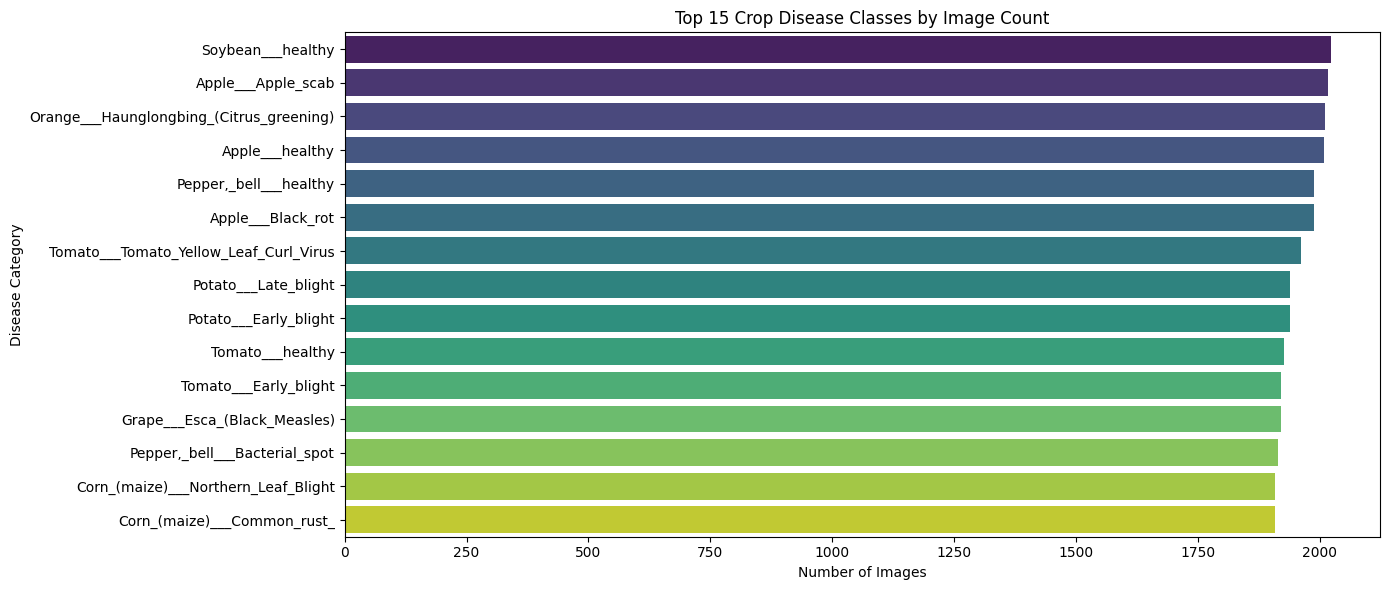

In [ ]:
# Cell 3: Data Inspection & Class Distribution Analysis
dataset_dir = "dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"

# Count images per class
class_counts = {}
for class_name in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

df_counts = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count']).sort_values(by='Count', ascending=False)

print(f"Total Classes: {len(df_counts)}")
print(f"Total Training Images: {df_counts['Count'].sum()}")

# Plot Class Distribution
plt.figure(figsize=(14, 6))
sns.barplot(data=df_counts.head(15), x='Count', y='Class', palette='viridis')
plt.title("Top 15 Crop Disease Classes by Image Count")
plt.xlabel("Number of Images")
plt.ylabel("Disease Category")
plt.tight_layout()
plt.show()

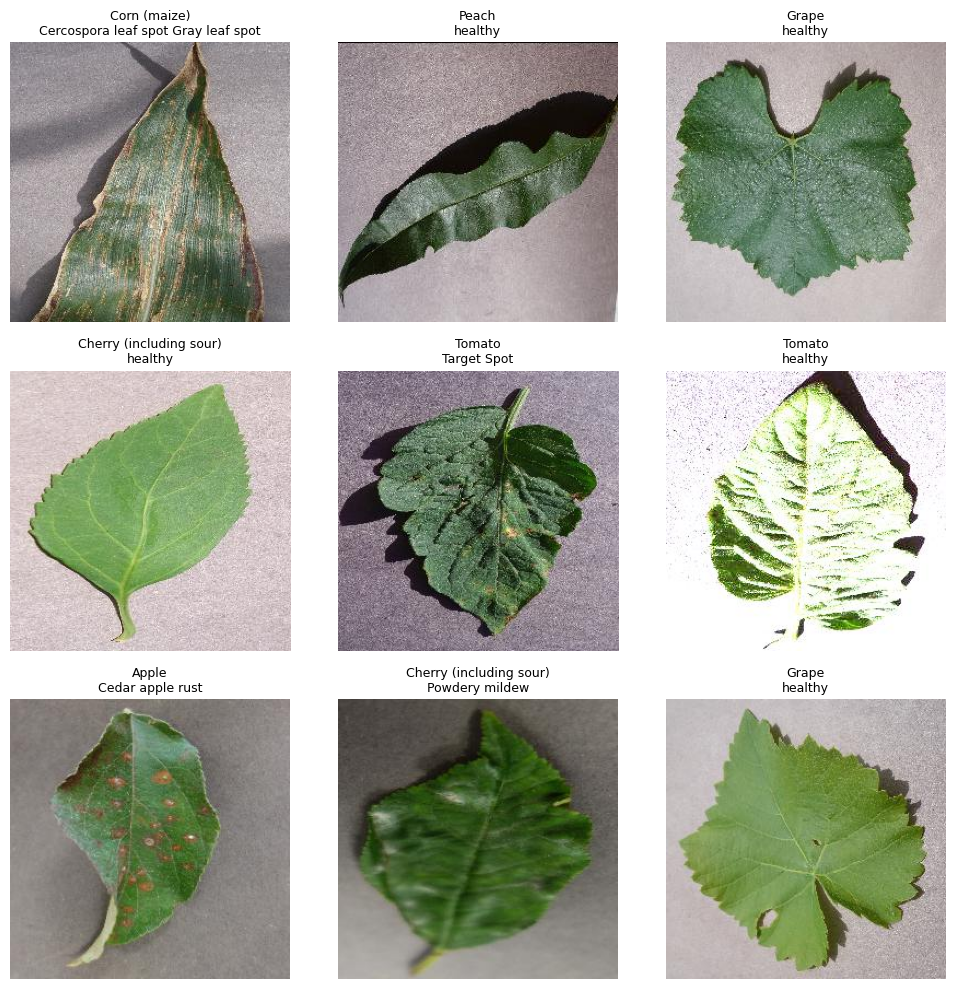

In [ ]:
# Cell 4: Visualizing Sample Images with Class Labels
classes = sorted([d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))])

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.ravel()

for i in range(9):
    random_class = random.choice(classes)
    class_path = os.path.join(dataset_dir, random_class)
    random_img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, random_img_name)

    img = Image.open(img_path)
    axes[i].imshow(img)
    # Format class name for better readability
    readable_label = random_class.replace("___", "\n").replace("_", " ")
    axes[i].set_title(readable_label, fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Cell 5: Data Augmentation & DataLoader Setup
IMG_SIZE = 224
BATCH_SIZE = 32

# Standard ImageNet normalization parameters
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Training transforms with field-condition data augmentation
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Validation/Test transforms (No augmentation, only scaling & normalization)
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

train_dir = "dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
val_dir = "dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

train_dataset = torchvision.datasets.ImageFolder(root=train_dir, transform=train_transforms)
val_dataset = torchvision.datasets.ImageFolder(root=val_dir, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Training samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")
print(f"Number of target classes: {len(train_dataset.classes)}")

Training samples: 70295 | Validation samples: 17572
Number of target classes: 38


## Part 2: Model Architecture & Transfer Learning Setup

In [ ]:
# Cell 6: Transfer Learning Model Builder (ResNet50 & MobileNetV3)
def build_crop_disease_model(model_name="resnet50", num_classes=38, pretrained=True, freeze_backbone=True):
    """
    Builds a computer vision model for plant disease classification using transfer learning.

    Args:
        model_name (str): 'resnet50' or 'mobilenet_v3'
        num_classes (int): Number of target crop disease categories
        pretrained (bool): Load ImageNet pre-trained weights
        freeze_backbone (bool): Freeze feature extractor layers initially
    """
    if model_name == "resnet50":
        weights = models.ResNet50_Weights.DEFAULT if pretrained else None
        model = models.resnet50(weights=weights)

        # Freeze backbone parameters if requested
        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False

        # Replace fully connected head
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    elif model_name == "mobilenet_v3":
        weights = models.MobileNet_V3_Large_Weights.DEFAULT if pretrained else None
        model = models.mobilenet_v3_large(weights=weights)

        # Freeze backbone parameters if requested
        if freeze_backbone:
            for param in model.features.parameters():
                param.requires_grad = False

        # Replace classifier head
        in_features = model.classifier[0].in_features
        model.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.Hardswish(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )
    else:
        raise ValueError("Unsupported model name. Choose 'resnet50' or 'mobilenet_v3'.")

    return model

# Instantiate ResNet50 baseline model
NUM_CLASSES = len(train_dataset.classes)
model = build_crop_disease_model(model_name="resnet50", num_classes=NUM_CLASSES, pretrained=True, freeze_backbone=True)
model = model.to(device)

print(f"Model successfully loaded on {device}.")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 93.3MB/s]


Model successfully loaded on cuda.


In [ ]:
# Cell 7: Layer Fine-Tuning Utility (Unfreezing Top Layers)
def unfreeze_backbone_top_layers(model, model_name="resnet50", num_blocks_to_unfreeze=2):
    """
    Selectively unfreezes top convolutional blocks for fine-tuning after initial head training.
    """
    if model_name == "resnet50":
        # ResNet50 has layer1, layer2, layer3, layer4
        layers_to_unfreeze = [model.layer4, model.layer3][-num_blocks_to_unfreeze:]
        for layer in layers_to_unfreeze:
            for param in layer.parameters():
                param.requires_grad = True
        print(f"Unfroze top {num_blocks_to_unfreeze} layer blocks in ResNet50 backbone.")

    elif model_name == "mobilenet_v3":
        # Unfreeze last N sub-modules of features
        for param in list(model.features.parameters())[-num_blocks_to_unfreeze * 5:]:
            param.requires_grad = True
        print(f"Unfroze top feature blocks in MobileNetV3 backbone.")

# Check trainable vs frozen parameters
def print_trainable_parameters(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Trainable Params: {trainable:,} | Total Params: {total:,} ({100 * trainable / total:.2f}% trainable)")

print_trainable_parameters(model)

Trainable Params: 1,068,582 | Total Params: 24,576,614 (4.35% trainable)


In [ ]:
# Cell 8: Loss Function with Class Weights & Optimizer Setup
from collections import Counter

# Calculate class weights to handle dataset imbalance
targets = [label for _, label in train_dataset.samples]
class_counts = Counter(targets)
total_samples = len(targets)

# Inverse class frequency weighting
class_weights = [total_samples / class_counts[i] for i in range(NUM_CLASSES)]
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

# Loss function with optional class weighting
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# AdamW Optimizer with differential learning rates (lower LR for backbone, higher for head)
def get_differential_optimizer(model, base_lr=1e-4, head_lr=1e-3):
    backbone_params = []
    head_params = []

    for name, param in model.named_parameters():
        if param.requires_grad:
            if "fc" in name or "classifier" in name:
                head_params.append(param)
            else:
                backbone_params.append(param)

    optimizer = optim.AdamW([
        {'params': backbone_params, 'lr': base_lr},
        {'params': head_params, 'lr': head_lr}
    ], weight_decay=1e-4)

    return optimizer

optimizer = get_differential_optimizer(model, base_lr=1e-4, head_lr=1e-3)

# Learning Rate Scheduler (Cosine Annealing)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

print("Optimizer and Weighted Cross-Entropy Loss configured successfully.")

Optimizer and Weighted Cross-Entropy Loss configured successfully.


## Part 3: Training Loop & Comprehensive Evaluation Metrics

In [ ]:
# Cell 9: Training & Validation Loop Engine with Early Stopping
import time
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

class EarlyStopping:
    """Early stops the training if validation loss doesn't improve after a given patience."""
    def __init__(self, patience=3, delta=0.001, path='best_crop_disease_model.pth'):
        self.patience = patience
        self.delta = delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.delta:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.path)
        print(f"Validation loss decreased. Saving best model checkpoint to {self.path}")


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=10, patience=3):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    early_stopping = EarlyStopping(patience=patience)

    for epoch in range(epochs):
        start_time = time.time()
        print(f"\n--- Epoch {epoch+1}/{epochs} ---")

        # --- Training Phase ---
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_train += torch.sum(preds == labels.data)
            total_train += labels.size(0)

        epoch_train_loss = running_loss / total_train
        epoch_train_acc = (correct_train.double() / total_train).item()

        # --- Validation Phase ---
        model.eval()
        val_running_loss, correct_val, total_val = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                correct_val += torch.sum(preds == labels.data)
                total_val += labels.size(0)

        epoch_val_loss = val_running_loss / total_val
        epoch_val_acc = (correct_val.double() / total_val).item()

        # Track history
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)

        # Update Scheduler
        scheduler.step(epoch_val_loss)

        elapsed = time.time() - start_time
        print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
        print(f"Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.4f} ({elapsed:.1f}s)")

        # Check Early Stopping
        early_stopping(epoch_val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping triggered! Training stopped.")
            break

    # Load best weights
    model.load_state_dict(torch.load('best_crop_disease_model.pth'))
    return model, history

# Execute Training
EPOCHS = 10
trained_model, history = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=EPOCHS, patience=3
)


--- Epoch 1/10 ---
Train Loss: 0.3935 | Train Acc: 0.8898
Val Loss:   0.1287 | Val Acc:   0.9598 (514.1s)
Validation loss decreased. Saving best model checkpoint to best_crop_disease_model.pth

--- Epoch 2/10 ---
Train Loss: 0.1743 | Train Acc: 0.9423
Val Loss:   0.0976 | Val Acc:   0.9676 (511.2s)
Validation loss decreased. Saving best model checkpoint to best_crop_disease_model.pth

--- Epoch 3/10 ---
Train Loss: 0.1485 | Train Acc: 0.9500
Val Loss:   0.0990 | Val Acc:   0.9668 (481.0s)
EarlyStopping counter: 1 out of 3

--- Epoch 4/10 ---
Train Loss: 0.1354 | Train Acc: 0.9545
Val Loss:   0.0900 | Val Acc:   0.9698 (486.2s)
Validation loss decreased. Saving best model checkpoint to best_crop_disease_model.pth

--- Epoch 5/10 ---
Train Loss: 0.1271 | Train Acc: 0.9573
Val Loss:   0.0786 | Val Acc:   0.9729 (476.0s)
Validation loss decreased. Saving best model checkpoint to best_crop_disease_model.pth

--- Epoch 6/10 ---
Train Loss: 0.1258 | Train Acc: 0.9584
Val Loss:   0.0643 | Val

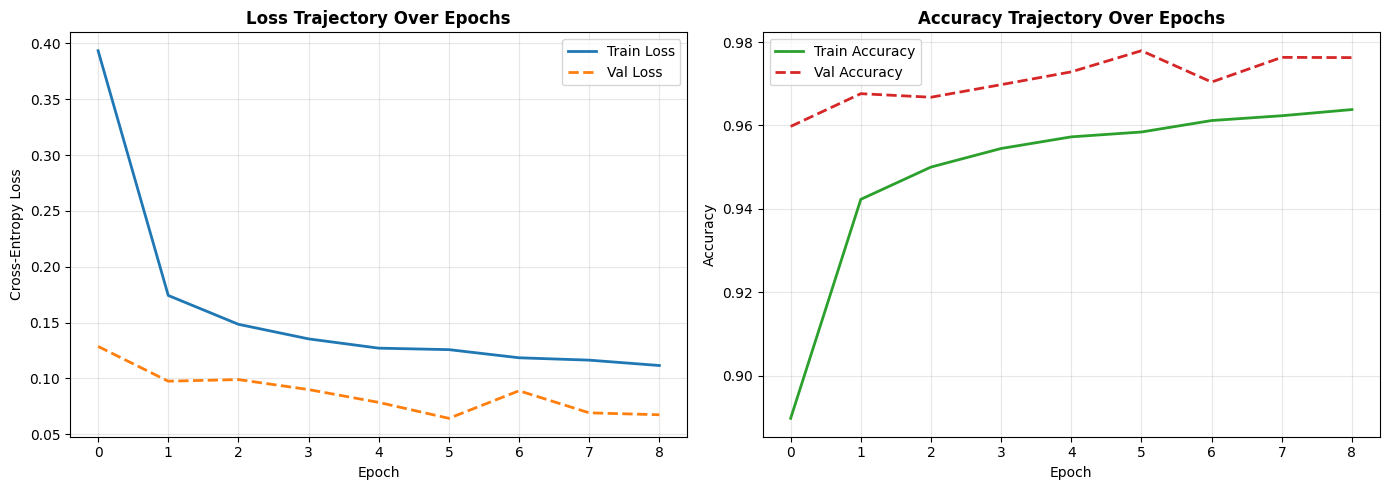

In [ ]:
# Cell 10: Training & Validation Curves Visualization
plt.figure(figsize=(14, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='#1f77b4', linewidth=2)
plt.plot(history['val_loss'], label='Val Loss', color='#ff7f0e', linewidth=2, linestyle='--')
plt.title('Loss Trajectory Over Epochs', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy', color='#2ca02c', linewidth=2)
plt.plot(history['val_acc'], label='Val Accuracy', color='#d62728', linewidth=2, linestyle='--')
plt.title('Accuracy Trajectory Over Epochs', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

 Macro Precision : 0.9787
 Macro Recall    : 0.9777
 Macro F1-Score  : 0.9779


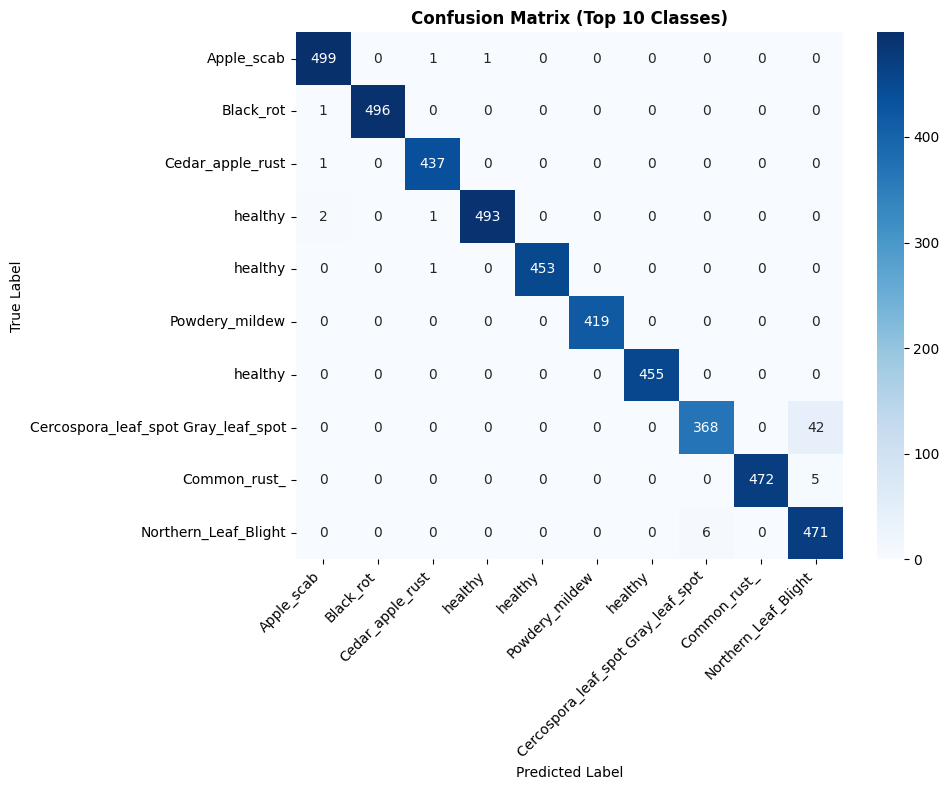

In [ ]:
# Cell 11: Detailed Evaluation & Confusion Matrix Analysis
def evaluate_model_metrics(model, dataloader, class_names):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())

    # Calculate Precision, Recall, F1
    precision, recall, f1, _ = precision_recall_fscore_support(all_targets, all_preds, average='macro')

    print("=" * 50)
    print(f" Macro Precision : {precision:.4f}")
    print(f" Macro Recall    : {recall:.4f}")
    print(f" Macro F1-Score  : {f1:.4f}")
    print("=" * 50)

    # Compute Confusion Matrix
    cm = confusion_matrix(all_targets, all_preds)

    # Plot top 10 classes for visual clarity if dataset has many classes
    num_display = min(10, len(class_names))
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm[:num_display, :num_display],
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=[c.split('___')[-1] for c in class_names[:num_display]],
        yticklabels=[c.split('___')[-1] for c in class_names[:num_display]]
    )
    plt.title(f'Confusion Matrix (Top {num_display} Classes)', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

evaluate_model_metrics(trained_model, val_loader, train_dataset.classes)

## Part 4: Visual Explainability (Grad-CAM) & Model Export

In [ ]:
# Cell 12: Grad-CAM Implementation for ResNet50
import cv2

class GradCAM:
    """
    Generates Gradient-based Class Activation Maps (Grad-CAM) to explain model predictions.
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Register hooks
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        # grad_output is a tuple; we need the gradient of the output w.r.t the input
        # Ensure grad_output is not None and has elements
        if grad_output is not None and len(grad_output) > 0:
            self.gradients = grad_output[0]
        else:
            self.gradients = None

    def generate_cam(self, input_image, target_class=None):
        self.model.eval()

        # Forward pass
        output = self.model(input_image)

        if target_class is None:
            target_class = torch.argmax(output, dim=1).item()

        # Zero gradients & backward pass for the target class
        self.model.zero_grad()
        score = output[0, target_class]
        score.backward()

        # Calculate Grad-CAM weights via Global Average Pooling of gradients
        if self.gradients is None:
            print("Warning: Gradients not captured for Grad-CAM. Ensure target_layer has requires_grad=True during backward pass.")
            return np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32), target_class # Return empty CAM or handle as appropriate

        gradients = self.gradients.data.cpu().numpy()[0]
        activations = self.activations.data.cpu().numpy()[0]

        weights = np.mean(gradients, axis=(1, 2))

        # Compute weighted sum of feature maps
        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * activations[i]

        # Apply ReLU to retain only positive influence
        cam = np.maximum(cam, 0)

        # Normalize heatmap between 0 and 1
        if cam.max() > 0:
            cam = cam / cam.max()

        # Resize heatmap to match original image dimensions (224x224)
        cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
        return cam, target_class

# Initialize Grad-CAM targeting the last convolutional layer of ResNet50 (layer4)
# Ensure the target_layer (model.layer4) has requires_grad=True for Grad-CAM to work.
# Even if the model was trained with frozen backbone, for Grad-CAM, we need gradients
# for the target layer.
for param in trained_model.layer4.parameters():
    param.requires_grad = True

grad_cam = GradCAM(model=trained_model, target_layer=trained_model.layer4)
print("Grad-CAM initialized successfully.")

Grad-CAM initialized successfully.


<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


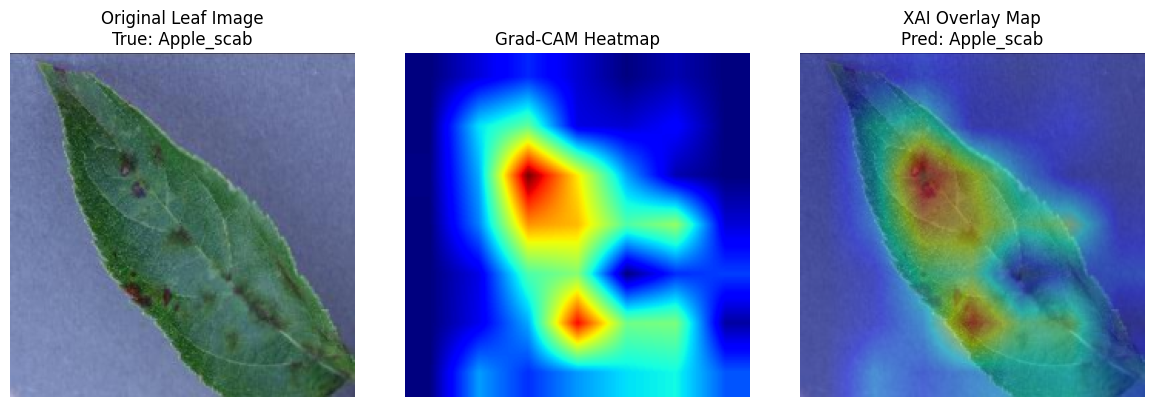

In [ ]:
# Cell 13: Plot Original Image, Heatmap Overlay, and Predictions
def visualize_gradcam_prediction(dataset, model, grad_cam, idx=0):
    # Fetch sample image and label
    img_tensor, true_label = dataset[idx]
    input_tensor = img_tensor.unsqueeze(0).to(device)

    # Generate CAM
    cam, pred_class = grad_cam.generate_cam(input_tensor)

    # Un-normalize image for visualization
    img_np = img_tensor.cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    # Create colored heatmap using OpenCV
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

    # Overlay heatmap on original image
    overlay = 0.6 * img_np + 0.4 * heatmap
    overlay = np.clip(overlay, 0, 1)

    # Display results
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(img_np)
    axes[0].set_title(f"Original Leaf Image\nTrue: {dataset.classes[true_label].split('___')[-1]}")
    axes[0].axis('off')

    axes[1].imshow(cam, cmap='jet')
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].axis('off')

    axes[2].imshow(overlay)
    axes[2].set_title(f"XAI Overlay Map\nPred: {dataset.classes[pred_class].split('___')[-1]}")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# Run Grad-CAM visualization on sample validation image
visualize_gradcam_prediction(val_dataset, trained_model, grad_cam, idx=15)

In [ ]:
# Updated Cell 14: PyTorch Modern ONNX Export
!pip install onnxscript -q

def export_model_to_onnx(model, save_path="crop_disease_resnet50.onnx"):
    model.eval()
    dummy_input = torch.randn(1, 3, 224, 224).to(device)

    # Modern PyTorch dynamic shapes specification
    batch_dim = torch.export.Dim("batch_size", min=1, max=64)
    # Corrected structure: dynamic_shapes should be a tuple, where each element is a dict specifying dynamic dimensions for the corresponding input tensor.
    dynamic_shapes = ({0: batch_dim},)

    torch.onnx.export(
        model,
        (dummy_input,),
        save_path,
        export_params=True,
        opset_version=18,  # Target PyTorch's native default opset
        dynamic_shapes=dynamic_shapes,
        input_names=['input_image'],
        output_names=['class_probabilities']
    )
    print(f"Model successfully exported to ONNX format at: '{save_path}'")

export_model_to_onnx(trained_model, save_path="crop_disease_resnet50.onnx")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.2/754.2 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 115.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 32.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.2 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.2 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.2 which is incompatible.
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain 

/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Model successfully exported to ONNX format at: 'crop_disease_resnet50.onnx'


In [ ]:
pip install streamlit torch torchvision opencv-python pillow numpy matplotlib seaborn onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 86.7 MB/s eta 0:00:00


## App

In [ ]:
!pip install pyngrok

## App

In [ ]:
!pip install streamlit pyngrok torchvision opencv-python plotly pandas -q

In [ ]:
%%writefile app.py
import streamlit as st
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import numpy as np
import cv2
import pandas as pd
import sqlite3
import os
from datetime import datetime

# --- Page Config ---
st.set_page_config(
    page_title="GreenVision Crop Disease Detector",
    page_icon="🌿",
    layout="wide"
)

# Custom Styling
st.markdown("""
    <style>
    .metric-card {
        background-color: #1e293b;
        padding: 15px;
        border-radius: 10px;
        border-left: 5px solid #10b981;
    }
    .treatment-card {
        background-color: #0f172a;
        padding: 20px;
        border-radius: 10px;
        border: 1px solid #334155;
    }
    </style>
""", unsafe_allow_html=True)

# --- SQLite Database Helper Functions ---
DB_NAME = "users.db"

def init_db():
    """Initialize SQLite database and create users table if it doesn't exist."""
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS registered_users (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            timestamp TEXT NOT NULL,
            full_name TEXT NOT NULL,
            contact_info TEXT NOT NULL,
            location TEXT NOT NULL
        )
    """)
    conn.commit()
    conn.close()

def log_user_to_db(name, contact, location):
    """Insert a new user record into the SQLite database."""
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    cursor.execute("""
        INSERT INTO registered_users (timestamp, full_name, contact_info, location)
        VALUES (?, ?, ?, ?)
    """, (timestamp, name, contact, location))
    conn.commit()
    conn.close()

def fetch_all_users():
    """Retrieve all logged users as a pandas DataFrame."""
    conn = sqlite3.connect(DB_NAME)
    df = pd.read_sql_query("SELECT * FROM registered_users ORDER BY id DESC", conn)
    conn.close()
    return df

# Initialize DB on load
init_db()

# Initialize Session State for User Registration
if "user_registered" not in st.session_state:
    st.session_state["user_registered"] = False
if "user_info" not in st.session_state:
    st.session_state["user_info"] = {}

# --- User Registration Gate ---
if not st.session_state["user_registered"]:
    st.title("🌿 GreenVision Crop Disease Detector")
    st.caption("User Registration & Diagnostic Portal")
    st.info("Welcome! Please register your details below to unlock the AI Diagnostic Engine.")

    with st.form("user_registration_form"):
        col1, col2 = st.columns(2)
        with col1:
            full_name = st.text_input("Full Name *", placeholder="e.g. Jane Doe")
            location = st.text_input("Location / Region *", placeholder="e.g. Nairobi, Kenya or Sector B Farm")
        with col2:
            contact_info = st.text_input("Email Address or Mobile Number *", placeholder="e.g. jane@example.com or +254700000000")

        submit_button = st.form_submit_button("Access Dashboard 🚀", use_container_width=True)

        if submit_button:
            if full_name.strip() and contact_info.strip() and location.strip():
                log_user_to_db(full_name.strip(), contact_info.strip(), location.strip())
                st.session_state["user_registered"] = True
                st.session_state["user_info"] = {
                    "name": full_name.strip(),
                    "contact": contact_info.strip(),
                    "location": location.strip()
                }
                st.success("Registration successful! Opening dashboard...")
                st.rerun()
            else:
                st.error("Please fill in all required fields (*).")
    st.stop()

# --- Full 38 PlantVillage Classes ---
CLASS_NAMES = [
    'Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy',
    'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy',
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_',
    'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot',
    'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy',
    'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy',
    'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight',
    'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy',
    'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy',
    'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight',
    'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite',
    'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus',
    'Tomato___healthy'
]

# --- Remediation & Treatment Database ---
TREATMENT_DB = {
    'Grape___Esca_(Black_Measles)': {
        'symptoms': 'Interveinal yellowing, brown "tiger-stripe" spots, vascular necrosis.',
        'chemical': 'Apply sodium arsenite or localized trunk sprays during dormant periods.',
        'organic': 'Prune infected vines 15cm below visible symptoms; seal wounds with wound sealant.',
        'prevention': 'Avoid pruning during wet weather; sanitize shears between cuts.'
    },
    'Tomato___Early_blight': {
        'symptoms': 'Concentric target-like rings on mature leaves, yellow halos.',
        'chemical': 'Apply copper-based fungicides, Chlorothalonil, or Mancozeb.',
        'organic': 'Neem oil spray, remove lower infected foliage.',
        'prevention': 'Ensure proper plant spacing and drip irrigation to keep foliage dry.'
    },
    'Potato___Late_blight': {
        'symptoms': 'Dark water-soaked lesions with white fungal growth underneath.',
        'chemical': 'Apply systemic fungicides like Metalaxyl or Cymoxanil.',
        'organic': 'Apply copper hydroxide spray before infection spreads.',
        'prevention': 'Destroy infected plant debris and practice 3-year crop rotation.'
    },
    'Apple___Apple_scab': {
        'symptoms': 'Olive-green to brown velvety spots on leaf surfaces.',
        'chemical': 'Apply Captan or Myclobutanil fungicides at green tip stage.',
        'organic': 'Sulfur-based sprays; rake and burn fallen autumn leaves.',
        'prevention': 'Plant scab-resistant cultivars and prune canopy for air circulation.'
    }
}

DEFAULT_TREATMENT = {
    'symptoms': 'Visible leaf tissue discoloration, spot lesions, or unusual foliage growth.',
    'chemical': 'Consult local agricultural extension office for targeted registered fungicides.',
    'organic': 'Prune affected foliage, avoid overhead watering, and apply neem oil solution.',
    'prevention': 'Maintain balanced soil nutrition, crop rotation, and adequate airflow.'
}

# --- Load Model ---
@st.cache_resource
def load_model():
    model = models.resnet50(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, len(CLASS_NAMES))
    )
    try:
        model.load_state_dict(torch.load('best_crop_disease_model.pth', map_location='cpu'))
    except FileNotFoundError:
        st.sidebar.warning("⚠️ Weights file not found. Using baseline weights.")
    model.eval()
    return model

model = load_model()

# --- Dynamic Grad-CAM Implementation ---
class DynamicGradCAM:
    def __init__(self, model, target_layer_name):
        self.model = model
        self.target_layer = dict([*self.model.named_modules()])[target_layer_name]
        self.gradients = None
        self.activations = None
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_cam(self, input_tensor):
        output = self.model(input_tensor)
        target_class = torch.argmax(output, dim=1).item()

        self.model.zero_grad()
        score = output[0, target_class]
        score.backward()

        gradients = self.gradients.data.cpu().numpy()[0]
        activations = self.activations.data.cpu().numpy()[0]
        weights = np.mean(gradients, axis=(1, 2))

        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = np.maximum(cam, 0)
        if cam.max() > 0:
            cam = cam / cam.max()

        cam = cv2.resize(cam, (224, 224))
        probs = torch.softmax(output, dim=1).detach().cpu().numpy()[0]
        return cam, target_class, probs

# --- Preprocessing Transforms ---
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- Dashboard Header & Sidebar ---
st.title("🌿 GreenVision Crop Disease Detector")
st.caption("Real-time classification & Grad-CAM visual explainability")

# Active User Badge
user_data = st.session_state["user_info"]
st.sidebar.markdown(f"### 👤 Active User Profile")
st.sidebar.write(f"**Name:** {user_data.get('name', 'N/A')}")
st.sidebar.write(f"**Contact:** {user_data.get('contact', 'N/A')}")
st.sidebar.write(f"**Location:** {user_data.get('location', 'N/A')}")

if st.sidebar.button("Logout / Register New User"):
    st.session_state["user_registered"] = False
    st.session_state["user_info"] = {}
    st.rerun()

st.sidebar.divider()

# --- Sidebar Controls ---
st.sidebar.header("⚙️ Diagnostics Settings")
uploaded_file = st.sidebar.file_uploader("Upload Leaf Image", type=["jpg", "jpeg", "png"])

st.sidebar.subheader("🎯 XAI Settings")
selected_layer = st.sidebar.selectbox("Target Conv Layer", ["layer4", "layer3", "layer2"], index=0)
alpha = st.sidebar.slider("Heatmap Blend Opacity", 0.0, 1.0, 0.5, 0.05)

colormap_choice = st.sidebar.selectbox(
    "Heatmap Color Map",
    ["JET (Standard)", "VIRIDIS (High Contrast)", "PLASMA (Thermal)", "HOT (Intensity)"]
)

COLORMAP_DICT = {
    "JET (Standard)": cv2.COLORMAP_JET,
    "VIRIDIS (High Contrast)": cv2.COLORMAP_VIRIDIS,
    "PLASMA (Thermal)": cv2.COLORMAP_PLASMA,
    "HOT (Intensity)": cv2.COLORMAP_HOT
}

st.sidebar.subheader("🛡️ Decision Gate")
min_confidence = st.sidebar.slider("Min Confidence Threshold (%)", 0, 100, 60, 5)

# --- Admin SQLite Viewer (Password Protected) ---
with st.sidebar.expander("🗄️ Admin: SQLite User Records"):
    admin_password = st.text_input("Enter Admin Password", type="password", key="admin_pass")
    if admin_password == "admin123":  # Set your preferred admin password here
        st.success("Access Granted")
        df_db_users = fetch_all_users()
        if not df_db_users.empty:
            st.dataframe(df_db_users, use_container_width=True)
        else:
            st.write("No records found in database.")
    elif admin_password:
        st.error("Incorrect Password")
    else:
        st.caption("🔒 Restricted to system administrators.")

# --- Main Diagnostic Body ---
if uploaded_file is not None:
    image = Image.open(uploaded_file).convert('RGB')
    input_tensor = transform(image).unsqueeze(0)

    # Run Dynamic Grad-CAM
    grad_cam = DynamicGradCAM(model, selected_layer)
    cam, pred_class, probs = grad_cam.generate_cam(input_tensor)

    top_class_name = CLASS_NAMES[pred_class]
    confidence = probs[pred_class] * 100
    formatted_label = top_class_name.replace("___", " - ").replace("_", " ")

    # Image Processing
    img_np = np.array(image.resize((224, 224))) / 255.0
    cmap_val = COLORMAP_DICT[colormap_choice]
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cmap_val)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = (1 - alpha) * img_np + alpha * heatmap
    overlay = np.clip(overlay, 0, 1)

    # --- Top Metrics Banner ---
    m1, m2, m3, m4 = st.columns(4)
    with m1:
        st.metric("Primary Diagnosis", formatted_label.split(" - ")[-1])
    with m2:
        st.metric("Crop Type", formatted_label.split(" - ")[0])
    with m3:
        st.metric("Model Confidence", f"{confidence:.2f}%")
    with m4:
        is_healthy = "healthy" in top_class_name.lower()
        st.metric("Health Status", "Healthy" if is_healthy else "Infected")

    st.divider()

    # Threshold Warning
    if confidence < min_confidence:
        st.warning(f"⚠️ Confidence ({confidence:.1f}%) is below your threshold setting ({min_confidence}%). Verification recommended.")

    # --- Visual Explainability Section ---
    st.subheader("🔍 Visual Explainability & Attention Overlay")
    col1, col2 = st.columns(2)
    with col1:
        st.image(img_np, caption="Input Leaf Image", use_container_width=True)
    with col2:
        st.image(overlay, caption="Interactive XAI Overlay (Grad-CAM)", use_container_width=True)

    st.divider()

    # --- Full Width Agricultural Recommendations ---
    st.subheader("📋 Agricultural Treatment Protocol")
    treatment_info = TREATMENT_DB.get(top_class_name, DEFAULT_TREATMENT)

    with st.expander("🔬 Symptom Profile", expanded=True):
        st.write(treatment_info['symptoms'])
    with st.expander("🧪 Recommended Chemical Control", expanded=False):
        st.write(treatment_info['chemical'])
    with st.expander("🌱 Organic / Cultural Remediation", expanded=False):
        st.write(treatment_info['organic'])
    with st.expander("🛡️ Preventive Measures", expanded=False):
        st.write(treatment_info['prevention'])

else:
    st.info("👈 Upload a crop leaf image in the sidebar to run the disease diagnosis model.")

Overwriting app.py


In [ ]:
import subprocess
from pyngrok import ngrok
from google.colab import userdata

# 1. Fetch token securely from Colab Secrets using its key name
ngrok_token = userdata.get('NGROK_AUTHTOKEN')
ngrok.set_auth_token(ngrok_token)

# 2. Terminate any existing Streamlit or Ngrok instances
!pkill streamlit
ngrok.kill()

# 3. Launch Streamlit in the background
subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501"])

# 4. Connect Ngrok tunnel
public_url = ngrok.connect(8501)
print(f"👉 Open your app here: {public_url}")

👉 Open your app here: NgrokTunnel: "https://mousy-astute-platonic.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
import torch

# Save trained weights to your Google Drive FYP1 folder
torch.save(model.state_dict(), '/content/drive/MyDrive/FYP1/best_crop_disease_model.pth')
print("✅ Weights safely saved to Google Drive!")

✅ Weights safely saved to Google Drive!
